# Modélisation du Scoring de Risque CNSS

Ce notebook réalise l'entraînement et la comparaison de trois modèles de classification (Random Forest, Régression Logistique, XGBoost) pour prédire le risque de défaut des affiliés CNSS.

**Pipeline général :**
1. Chargement des données depuis Oracle
2. Préparation des features et split train/test
3. Normalisation des données
4. Optimisation des hyperparamètres avec Optuna
5. Évaluation et comparaison des modèles


In [1]:
# Importation des librairies nécessaires
# - pandas/numpy       : manipulation et calcul sur les données
# - oracledb           : connexion à la base Oracle
# - optuna             : optimisation bayésienne des hyperparamètres
# - sklearn            : modèles ML, métriques, preprocessing
# - xgboost            : algorithme de boosting de gradient
import pandas as pd
import numpy as np
import oracledb
import optuna

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.preprocessing import StandardScaler

## 1. Chargement des Données

In [2]:
# Connexion à la base de données Oracle locale
# Chargement complet de la table dataset_final1 dans un DataFrame pandas
conn = oracledb.connect(
    user="pfe",
    password="pfe",
    dsn="127.0.0.1:1521/XEPDB1"
)

query = "SELECT * FROM dataset_final1"
df = pd.read_sql(query, conn)

C:\Users\fatimazahra\AppData\Local\Temp\ipykernel_9336\3602011780.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


## 2. Préparation des Variables

In [3]:
# Extraction de la variable cible (TARGET_FLAG_CLEAN : 1=défaut, 0=sain)
# Suppression des colonnes non pertinentes pour la modélisation :
#   - Libellés textuels (redondants avec les IDs)
#   - Autres variables cibles (pour éviter la fuite de données)
# Construction de la matrice de features X
y = df["TARGET_FLAG_CLEAN"]

df = df.drop(columns=[
    "LIBELLE_SECTEUR",
    "LIBELLE_REGION",
    "LIBELLE_VILLE",
    "TARGET_RECOUVREMENT",
    "TARGET_POURCENTAGE_IMPAYE",
    "TARGET_POURCENTAGE_PAYE",
    "FLAG_GLOBAL",
    "TARGET_RECOUVREMENT_PAYE",
])

X = df.drop("TARGET_FLAG_CLEAN", axis=1)

## 3. Split Train / Test

In [4]:
# Split par NUM_AFF pour éviter toute fuite de données entre train et test.
# Les affiliés sont mélangés aléatoirement (seed=42 pour reproductibilité),
# puis les 130 000 premiers sont assignés au train, le reste au test.
affilies = df["NUM_AFF"].unique()

np.random.seed(42)
np.random.shuffle(affilies)

train_aff = affilies[:130000]
test_aff  = affilies[130000:]

train_df = df[df["NUM_AFF"].isin(train_aff)].copy()
test_df  = df[df["NUM_AFF"].isin(test_aff)].copy()

y_train = train_df["TARGET_FLAG_CLEAN"]
X_train = train_df.drop(columns=["TARGET_FLAG_CLEAN"])

y_test = test_df["TARGET_FLAG_CLEAN"]
X_test = test_df.drop(columns=["TARGET_FLAG_CLEAN"])


## 4. Normalisation des Features

In [5]:
# Sélection des colonnes numériques uniquement (int64/float64).
# StandardScaler centre et réduit les données (moyenne=0, écart-type=1).
# Le scaler est fitté uniquement sur le train pour éviter le data leakage.
X_train = X_train.select_dtypes(include=["int64", "float64"])
X_test = X_test.select_dtypes(include=["int64", "float64"])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Gestion du Déséquilibre de Classes

In [6]:
# Calcul du ratio classe majoritaire / classe minoritaire.
# Ce poids sera utilisé par XGBoost pour pénaliser davantage les erreurs
# sur la classe minoritaire (défauts), qui est sous-représentée dans les données.
#gestion de desiquilibre
# poids automatique
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("Scale_pos_weight:", scale_pos_weight)

Scale_pos_weight: 10.52073732718894


## 6. Définition des Fonctions Objectif pour Optuna

In [7]:
# Fonction objectif pour l'optimisation du Random Forest.
# Optuna teste différentes combinaisons de n_estimators et max_depth
# et retourne l'AUC-ROC comme métrique à maximiser.
# class_weight='balanced' compense le déséquilibre des classes.
def rf_objective(trial):

    model = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 100, 400),
        max_depth=trial.suggest_int("max_depth", 3, 20),
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    )

    model.fit(X_train, y_train)

    proba = model.predict_proba(X_test)[:, 1]

    return roc_auc_score(y_test, proba)

In [8]:
# Fonction objectif pour la Régression Logistique.
# Le paramètre C contrôle la régularisation (plus C est grand, moins il y a de régularisation).
# Utilise les données normalisées (X_train_scaled) car LR est sensible à l'échelle.
def lr_objective(trial):

    model = LogisticRegression(
        C=trial.suggest_float("C", 0.01, 10),
        solver="liblinear",
        max_iter=3000,
        class_weight="balanced"
    )

    model.fit(X_train_scaled, y_train)

    proba = model.predict_proba(X_test_scaled)[:, 1]

    return roc_auc_score(y_test, proba)

In [9]:
# Fonction objectif pour XGBoost.
# Optimise simultanément : le nombre d'arbres, la profondeur, le taux d'apprentissage
# et le scale_pos_weight pour gérer le déséquilibre des classes.
# tree_method='hist' accélère l'entraînement sur de grands jeux de données.
def xgb_objective(trial):

    model = XGBClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 400),
        max_depth=trial.suggest_int("max_depth", 3, 8),
        learning_rate=trial.suggest_float("learning_rate", 0.05, 0.2),
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=trial.suggest_float("scale_pos_weight", 5, 20),
        tree_method="hist",
        eval_metric="logloss",
        random_state=42
    )

    model.fit(X_train_scaled, y_train)

    proba = model.predict_proba(X_test_scaled)[:, 1]

    return roc_auc_score(y_test, proba)


## 7. Lancement de l'Optimisation Optuna

In [10]:
# Lancement de l'étude Optuna pour le Random Forest (30 essais)
study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(rf_objective, n_trials=30)



[I 2026-05-06 10:48:48,029] A new study created in memory with name: no-name-3dd9dfca-a33c-4a52-b366-8226872b066b
[I 2026-05-06 10:49:21,684] Trial 0 finished with value: 0.9780078056299605 and parameters: {'n_estimators': 112, 'max_depth': 9}. Best is trial 0 with value: 0.9780078056299605.
[I 2026-05-06 10:50:04,489] Trial 1 finished with value: 0.9778786459038488 and parameters: {'n_estimators': 164, 'max_depth': 4}. Best is trial 0 with value: 0.9780078056299605.
[I 2026-05-06 10:52:17,613] Trial 2 finished with value: 0.978004129673978 and parameters: {'n_estimators': 340, 'max_depth': 9}. Best is trial 0 with value: 0.9780078056299605.
[I 2026-05-06 10:53:58,082] Trial 3 finished with value: 0.9773016879035079 and parameters: {'n_estimators': 286, 'max_depth': 14}. Best is trial 0 with value: 0.9780078056299605.
[I 2026-05-06 10:55:24,200] Trial 4 finished with value: 0.976992561488241 and parameters: {'n_estimators': 303, 'max_depth': 18}. Best is trial 0 with value: 0.978007805

In [11]:
# Lancement de l'étude Optuna pour la Régression Logistique (30 essais)
study_lr = optuna.create_study(direction="maximize")
study_lr.optimize(lr_objective, n_trials=30)

[I 2026-05-06 11:23:50,621] A new study created in memory with name: no-name-92d529cb-c6b0-4f70-b84a-1f33f4b728ae
[I 2026-05-06 11:24:08,818] Trial 0 finished with value: 0.9775503161990502 and parameters: {'C': 1.965752836843899}. Best is trial 0 with value: 0.9775503161990502.
[I 2026-05-06 11:24:22,860] Trial 1 finished with value: 0.977860552562065 and parameters: {'C': 3.1021634605834496}. Best is trial 1 with value: 0.977860552562065.
[I 2026-05-06 11:24:37,232] Trial 2 finished with value: 0.9782345691483603 and parameters: {'C': 9.548500397073772}. Best is trial 2 with value: 0.9782345691483603.
[I 2026-05-06 11:24:56,809] Trial 3 finished with value: 0.9781525762340758 and parameters: {'C': 6.095996238527452}. Best is trial 2 with value: 0.9782345691483603.
[I 2026-05-06 11:25:24,248] Trial 4 finished with value: 0.9780866238549875 and parameters: {'C': 4.984034331043285}. Best is trial 2 with value: 0.9782345691483603.
[I 2026-05-06 11:25:26,925] Trial 5 finished with value: 

In [12]:
# Lancement de l'étude Optuna pour XGBoost (30 essais)
study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(xgb_objective, n_trials=30)

[I 2026-05-06 11:30:09,752] A new study created in memory with name: no-name-7f3559e3-99ae-4367-ba1d-8d8a201b0e19


[I 2026-05-06 11:30:25,773] Trial 0 finished with value: 0.9774304179724266 and parameters: {'n_estimators': 341, 'max_depth': 6, 'learning_rate': 0.06601676873628591, 'scale_pos_weight': 18.847198516450547}. Best is trial 0 with value: 0.9774304179724266.
[I 2026-05-06 11:30:34,330] Trial 1 finished with value: 0.9775113128738854 and parameters: {'n_estimators': 212, 'max_depth': 5, 'learning_rate': 0.1250820417977716, 'scale_pos_weight': 11.303101141105174}. Best is trial 1 with value: 0.9775113128738854.
[I 2026-05-06 11:30:44,353] Trial 2 finished with value: 0.977622343453447 and parameters: {'n_estimators': 308, 'max_depth': 3, 'learning_rate': 0.1900592517254474, 'scale_pos_weight': 11.582099864198874}. Best is trial 2 with value: 0.977622343453447.
[I 2026-05-06 11:30:52,503] Trial 3 finished with value: 0.9775385006262491 and parameters: {'n_estimators': 231, 'max_depth': 4, 'learning_rate': 0.1671864771068839, 'scale_pos_weight': 15.090020345979815}. Best is trial 2 with valu

## 8. Évaluation des Modèles

In [13]:
# Fonction d'évaluation générique applicable à tout modèle.
# Calcule et affiche :
#   - AUC-ROC : mesure la capacité de discrimination (plus proche de 1 = meilleur)
#   - Gini    : 2*AUC - 1, version normalisée de l'AUC (entre 0 et 1)
#   - Matrice de confusion : vrais/faux positifs et négatifs
#   - Rapport de classification : précision, rappel, F1 par classe
from sklearn.metrics import classification_report, confusion_matrix, roc_curve

def evaluate_model(y_test, y_proba, y_pred, name):

    auc = roc_auc_score(y_test, y_proba)
    gini = 2 * auc - 1

    print("\n=====", name, "=====")
    print("AUC :", auc)
    print("Gini:", gini)

    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))


===== RF =====
AUC : 0.9783068947758077
Gini: 0.9566137895516154

Confusion Matrix:
 [[20266   556]
 [  572  1440]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97     20822
           1       0.72      0.72      0.72      2012

    accuracy                           0.95     22834
   macro avg       0.85      0.84      0.85     22834
weighted avg       0.95      0.95      0.95     22834



c:\Users\fatimazahra\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



===== LR =====
AUC : 0.9743642887655338
Gini: 0.9487285775310677

Confusion Matrix:
 [[20298   524]
 [  714  1298]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97     20822
           1       0.71      0.65      0.68      2012

    accuracy                           0.95     22834
   macro avg       0.84      0.81      0.82     22834
weighted avg       0.94      0.95      0.94     22834

 Meilleur seuil trouvé : 0.8140
   → Précision classe 1 : 0.64 | Recall : 0.88 | F1 : 0.74


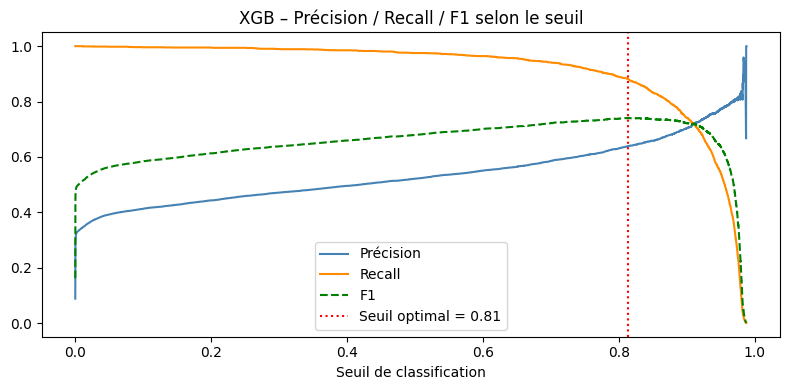


===== XGB (seuil optimisé) =====
AUC : 0.9781103146751993
Gini: 0.9562206293503985

Confusion Matrix:
 [[19821  1001]
 [  239  1773]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.95      0.97     20822
           1       0.64      0.88      0.74      2012

    accuracy                           0.95     22834
   macro avg       0.81      0.92      0.86     22834
weighted avg       0.96      0.95      0.95     22834



In [14]:
# Entraînement des trois modèles avec les meilleurs hyperparamètres trouvés par Optuna.
# Prédiction des probabilités et des classes sur le jeu de test.
# Appel de evaluate_model() pour afficher les métriques de chaque modèle.
# RF
best_rf = RandomForestClassifier(**study_rf.best_params, random_state=42)
best_rf.fit(X_train, y_train)

y_proba_rf = best_rf.predict_proba(X_test)[:, 1]
y_pred_rf = best_rf.predict(X_test)

evaluate_model(y_test, y_proba_rf, y_pred_rf, "RF")


# LR
best_lr = LogisticRegression(**study_lr.best_params, max_iter=2000)
best_lr.fit(X_train, y_train)

y_proba_lr = best_lr.predict_proba(X_test)[:, 1]
y_pred_lr = best_lr.predict(X_test)

evaluate_model(y_test, y_proba_lr, y_pred_lr, "LR")


# XGB
best_xgb = XGBClassifier(**study_xgb.best_params, random_state=42)
best_xgb.fit(X_train_scaled, y_train)

y_proba_xgb = best_xgb.predict_proba(X_test_scaled)[:, 1]

# ── Recherche du seuil optimal (maximise F1 classe 1) ──────────────────
from sklearn.metrics import precision_recall_curve, f1_score
import matplotlib.pyplot as plt

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_xgb)

f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-9)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]
print(f" Meilleur seuil trouvé : {best_threshold:.4f}")
print(f"   → Précision classe 1 : {precisions[best_idx]:.2f} | Recall : {recalls[best_idx]:.2f} | F1 : {f1_scores[best_idx]:.2f}")

# Courbe Précision / Recall
plt.figure(figsize=(8, 4))
plt.plot(thresholds, precisions[:-1], label="Précision", color="steelblue")
plt.plot(thresholds, recalls[:-1],   label="Recall",    color="darkorange")
plt.plot(thresholds, f1_scores,      label="F1",        color="green", linestyle="--")
plt.axvline(best_threshold, color="red", linestyle=":", label=f"Seuil optimal = {best_threshold:.2f}")
plt.xlabel("Seuil de classification")
plt.title("XGB – Précision / Recall / F1 selon le seuil")
plt.legend()
plt.tight_layout()
plt.show()

# ── Évaluation avec le seuil optimal ───────────────────────────────────
y_pred_xgb = (y_proba_xgb >= best_threshold).astype(int)
evaluate_model(y_test, y_proba_xgb, y_pred_xgb, "XGB (seuil optimisé)")

## 9. Comparaison Finale des Modèles

In [15]:
# Tableau récapitulatif des AUC-ROC des trois modèles.
# Résultats obtenus :
#   RF   : 0.978321
#   XGB  : 0.978266
#   LR   : 0.974466

# On remarque que Random Forest et XGBoost ont des performances très proches,
# avec une différence d’AUC presque négligeable.

# Même si RF est légèrement meilleur en AUC, j’ai choisi de retenir XGBoost
# comme modèle final pour le scoring.

# Ce choix est basé sur le fait que XGBoost est souvent plus robuste,
# mieux adapté aux problèmes de classification complexe,
# et très utilisé dans les modèles de scoring en pratique.
results = pd.DataFrame({
    "Model": ["RF", "LR", "XGB"],
    "AUC": [
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_xgb)
    ]
})

print(results.sort_values("AUC", ascending=False))
#  Model       AUC
#2   XGB  0.986727
#0    RF  0.986367
#1    LR  0.974751

  Model       AUC
0    RF  0.978307
2   XGB  0.978110
1    LR  0.974364


## 10. Sauvegarde du Modèle et des Artefacts

In [16]:
# =========================
# SAVE FINAL MODEL FROM OPTUNA
# =========================

import os
import joblib
from xgboost import XGBClassifier

#  Dossier de sauvegarde
MODEL_DIR = "models_v2"
os.makedirs(MODEL_DIR, exist_ok=True)

# =========================
# 1. Récupérer les meilleurs paramètres Optuna
# =========================

best_params = study_xgb.best_params
print("Best params:", best_params)

# =========================
# 2. Construire le modèle final
# =========================

final_model = XGBClassifier(
    **best_params,
    eval_metric="logloss",
    random_state=42
)

# =========================
# 3. Entraînement sur TOUTES les données
# =========================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

final_model.fit(X_scaled, y)

# =========================
# 4. Sauvegarde
# =========================

joblib.dump(final_model, os.path.join(MODEL_DIR, "model_v2.pkl"))
joblib.dump(scaler, os.path.join(MODEL_DIR, "scaler_v2.pkl"))
joblib.dump(list(X.columns), os.path.join(MODEL_DIR, "features_v2.pkl"))

print(" Modèle final (Optuna) sauvegardé avec succès !")

Best params: {'n_estimators': 251, 'max_depth': 4, 'learning_rate': 0.06248921045418106, 'scale_pos_weight': 10.40628126038849}
 Modèle final (Optuna) sauvegardé avec succès !


In [17]:
# =========================
# TEST RAPIDE DU MODELE FINAL
# =========================

loaded_model = joblib.load("models_v2/model_v2.pkl")
loaded_scaler = joblib.load("models_v2/scaler_v2.pkl")

X_test_scaled = loaded_scaler.transform(X)

proba = loaded_model.predict_proba(X_test_scaled)[:,1]

print("Min proba:", proba.min())
print("Max proba:", proba.max())
print("Mean proba:", proba.mean())

Min proba: 7.15854e-07
Max proba: 0.98944855
Mean proba: 0.15850483
